In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
data = {
    'jam_ngoding'   :[35, 40, 25, 22, 32, 20, 15, 35, 28, 10],
    'kehadiran_(%)' :[100, 80, 90, 100, 70, 80, 100, 50, 60, 50],
    'spek_teknis'   :[9, 8, 8, 10, 6, 7, 9, 4, 5, 5],
    'story_points'  :[45, 42, 32, 35, 28, 25, 22, 20, 18, 10],
}

df = pd.DataFrame(data)
print(df)

   jam_ngoding  kehadiran_(%)  spek_teknis  story_points
0           35            100            9            45
1           40             80            8            42
2           25             90            8            32
3           22            100           10            35
4           32             70            6            28
5           20             80            7            25
6           15            100            9            22
7           35             50            4            20
8           28             60            5            18
9           10             50            5            10


In [ ]:
X = df[['jam_ngoding', 'kehadiran_(%)', 'spek_teknis']]
Y = df['story_points']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)

Intercept (a): -18.94743183259348
Koefisien (b1, b2, b3): [ 0.80856056 -0.14603678  5.26176284]


In [ ]:
Y_pred = model.predict(X_test)

print("Prediksi:", Y_pred)
print("Point Asli:", Y_test.values)

Prediksi: [21.23887127 43.80615092]
Point Asli: [18 42]


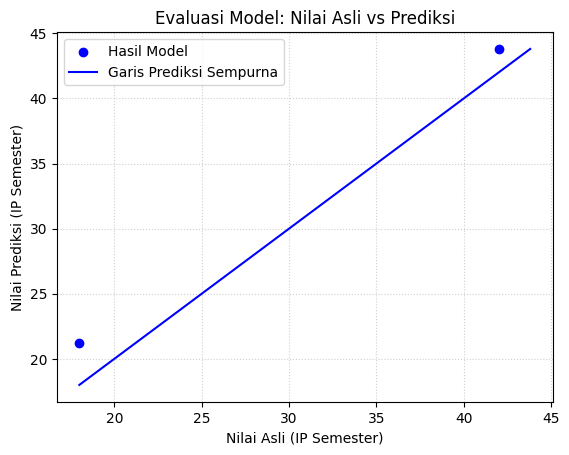

In [ ]:
# Gambar titik tebakan vs kenyataan
plt.scatter(Y_test, Y_pred, color='blue', label='Hasil Model')

# Gambar garis bantu diagonal (Garis Sempurna)
# Titik yang jatuh di atas garis ini berarti tebakan model = nilai asli
min_val = min(min(Y_test), min(Y_pred))
max_val = max(max(Y_test), max(Y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='blue', label='Garis Prediksi Sempurna')

plt.xlabel('Nilai Asli (IP Semester)')
plt.ylabel('Nilai Prediksi (IP Semester)')
plt.title('Evaluasi Model: Nilai Asli vs Prediksi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
print("MAE:", metrics.mean_absolute_error(Y_test, Y_pred))
print("MSE:", metrics.mean_squared_error(Y_test, Y_pred))
print("RMSE:", np.sqrt,(metrics.mean_squared_error(Y_test, Y_pred)))

MAE: 2.522511097019674
MSE: 6.876234138570187
RMSE: <ufunc 'sqrt'> 6.876234138570187


In [ ]:
data_baru = [[3, 46, 9]]
prediksi = model.predict(data_baru)

print("Prediksi point worker:", prediksi[0])

Prediksi point worker: 24.116423589093245


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Faktor Dominan: Fitur 'spek_teknis' memiliki koefisien tertinggi (5.26), jauh melampaui jam ngoding (0.80) dan kehadiran (-0.14).

Interpretasi: Kualitas perangkat keras (spek teknis) adalah kunci utama produktivitas tim dalam menyelesaikan tugas.

Evaluasi: Model memiliki MAE sebesar 2.52, yang berarti prediksi poin pekerja meleset rata-rata sekitar 2.5 poin dari nilai asli.